# ****PREDIKSI TINGKAT PENJUALAN**** (Menggunakan Multiple Linear Regression)

**Modul 1** (Data Understanding)

*   Import library

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

* Import CSV

In [2]:
df = pd.read_csv('Advertising.csv')

* Melihat 5 data teratas

In [3]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


* Melihat 5 data terbawah

In [4]:
df.tail()

,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


* Deskripsi data

In [5]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


* Informasi data

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


* Melihat data kosong

In [7]:
df.isna().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

*   * Tidak ada data yang kosong

* Melihat data duplikat

In [8]:
def cek_duplicate(df):
    duplicated_df = df[df.duplicated(keep = False)]
    index_list = duplicated_df.index.to_list()
    print(f'Kolom yang Teridetifikasi Duplikat : ')
    print (duplicated_df)
    print (f'jumblah Duplikat Data {df.duplicated().sum()}')
    print (f'Baris : {index_list}')

In [9]:
cek_duplicate(df)

Kolom yang Teridetifikasi Duplikat : 
Empty DataFrame
Columns: [Unnamed: 0, TV, Radio, Newspaper, Sales]
Index: []
jumblah Duplikat Data 0
Baris : []


*   * Tidak ada data yang teridemtifikasi duplikat

**MODUL 2** (EDA)

* Melihat distribusi data (Menggunakan histplot)

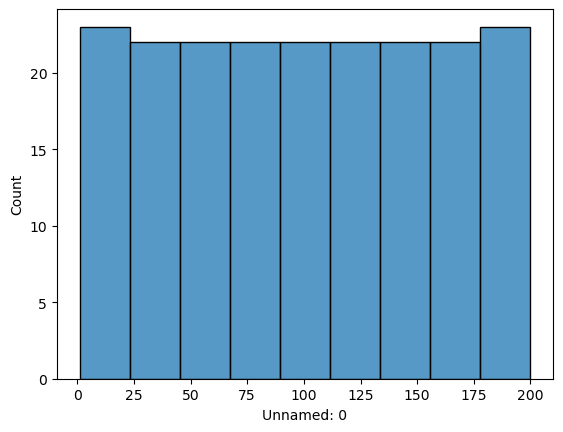

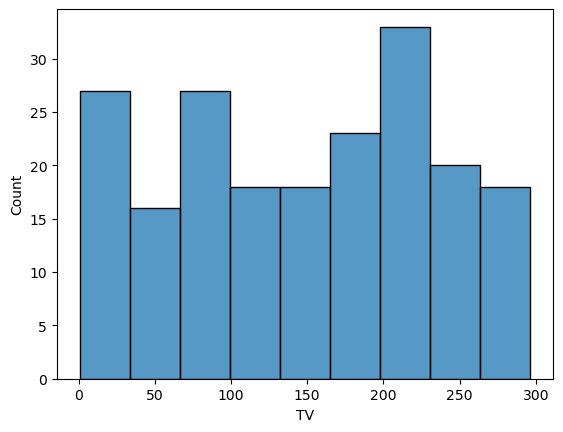

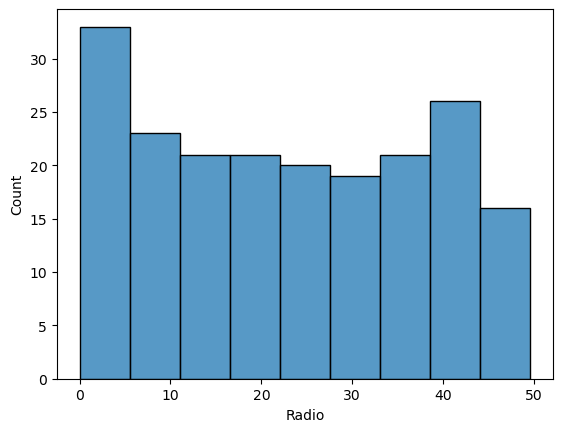

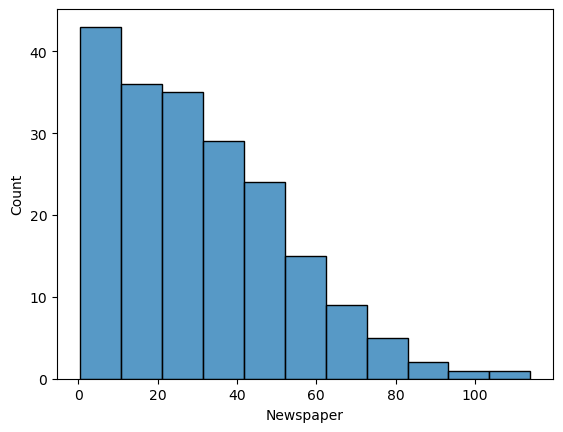

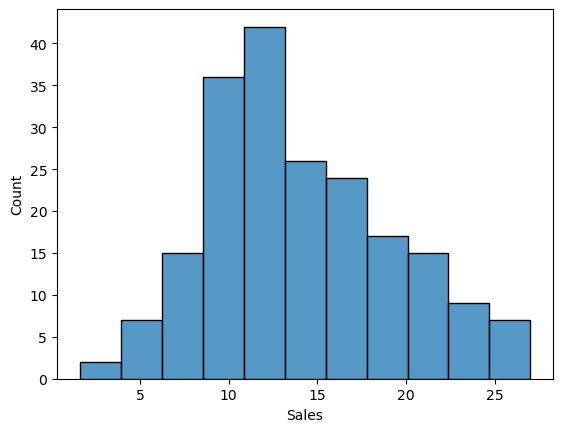

In [10]:
for i in df.columns:
    sns.histplot(df[i])
    plt.show()

* Melihat Outlier (Menggunakan boxplot)

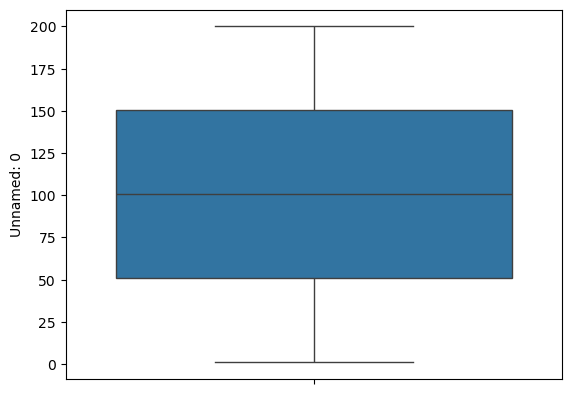

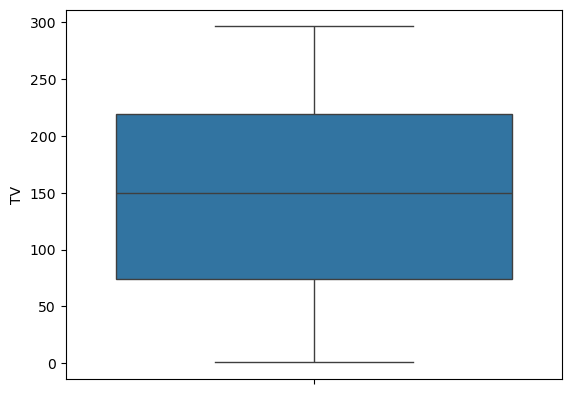

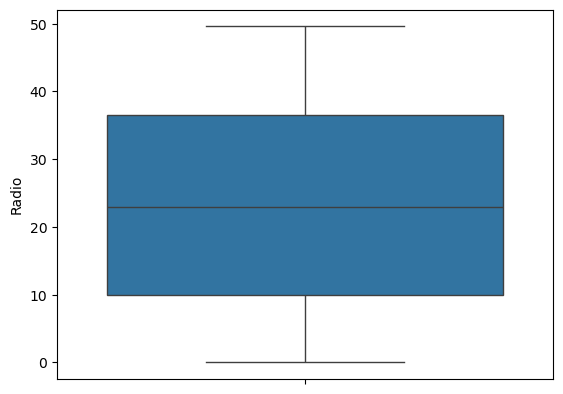

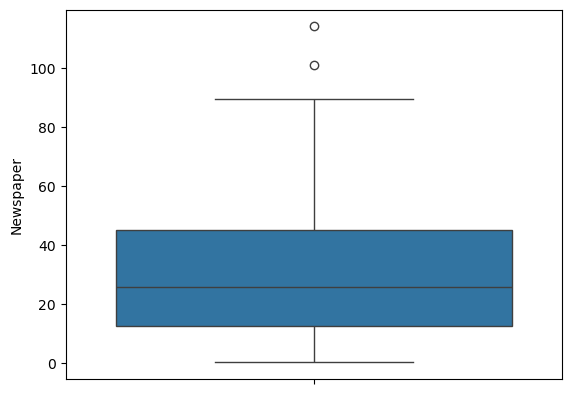

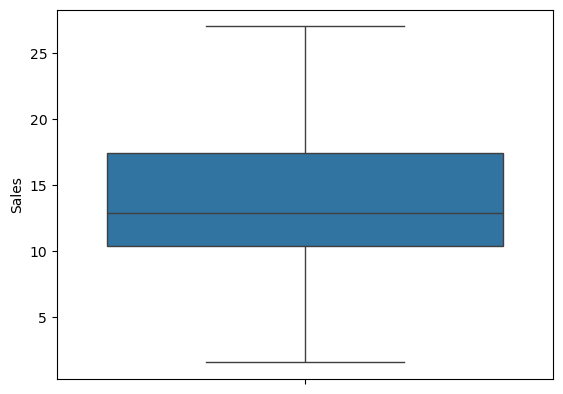

In [11]:
for i in df.columns:
    sns.boxplot(df[i])
    plt.show()

*   * Terdapat outlier di NewsPaper

* Melihat hubungan Korelasi

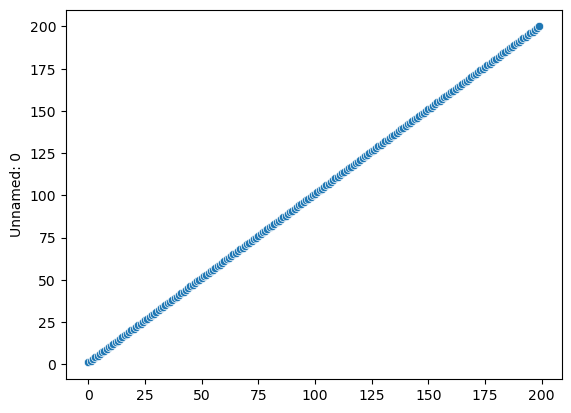

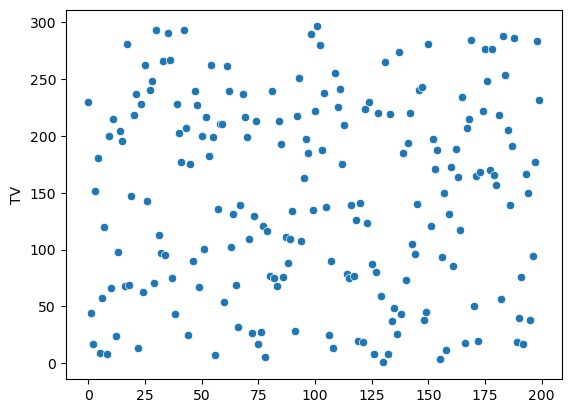

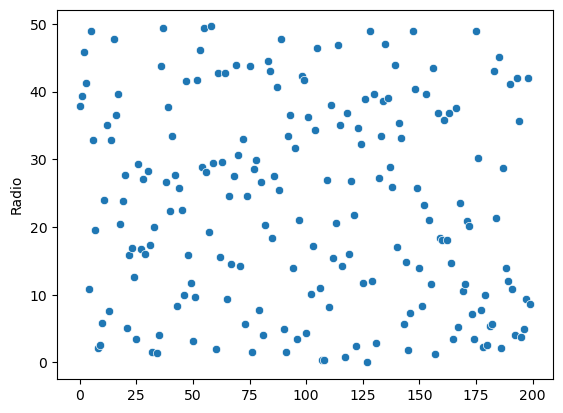

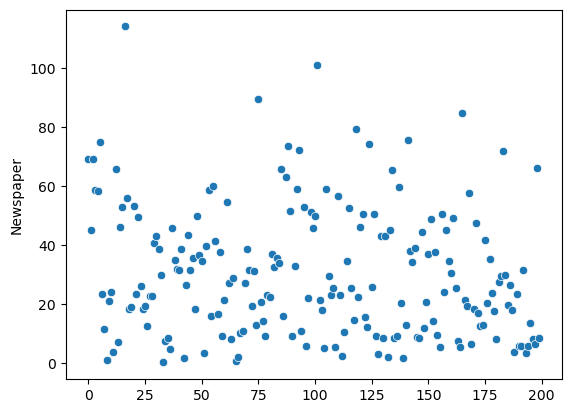

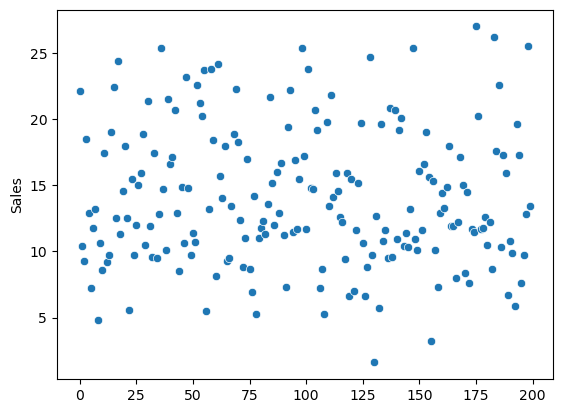

In [12]:
for i in df.columns:
    sns.scatterplot(df[i])
    plt.show()

* Melihat informasi data keseluruhan (Menggunakan Pairplot)

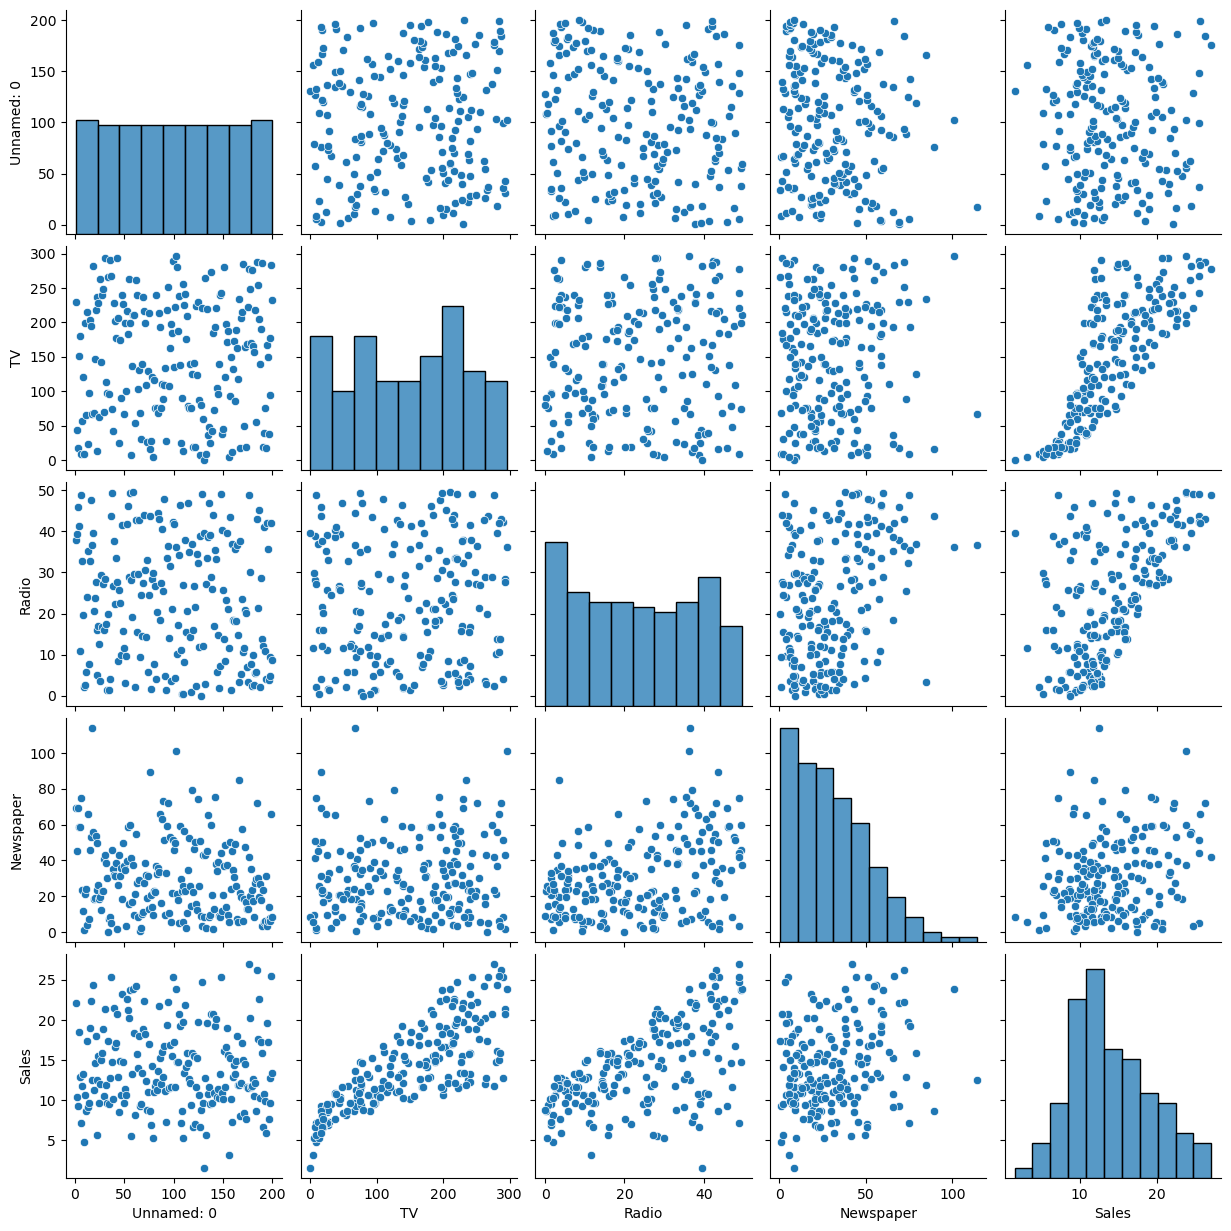

In [13]:
sns.pairplot(df)
plt.show()

*   * *Data yang tidak akan di ginakan (Unnamed: 0)*

* Melihat korelasi data (Menggunakan Heatmap)

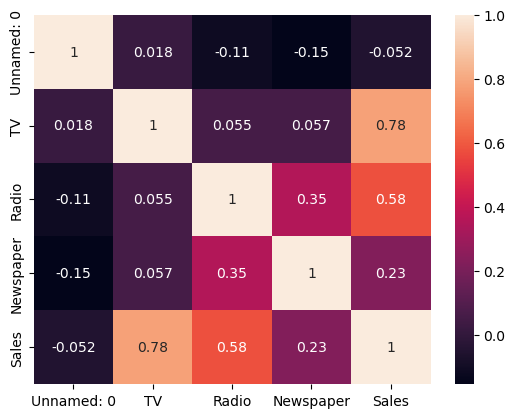

In [14]:
sns.heatmap(df.corr(), annot= True)
plt.show()

**MODUL 3**

*   * Sedikit dari modul 3 yang di kerjakan karena tidak ada data duplikat dan data kosong yang harus di kerjakan

In [15]:
df.drop('Unnamed: 0', axis=1, inplace= True)

*   * Menghapus data yang tidak di gunakan

* Menentukan IQR (Menemukan outlier)

In [16]:
Q1 = df['Newspaper'].quantile(0.25)
Q3 = df['Newspaper'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[
    (df['Newspaper'] >= lower_bound) &
    (df['Newspaper'] <= upper_bound)
]

In [17]:
print ('Q1: ', Q1)
print ('Q3: ', Q3)
print ('IQR: ', IQR)
print ('Lower Bound: ', lower_bound)
print ('Upper Bound: ', upper_bound)

Q1:  12.75
Q3:  45.1
IQR:  32.35
Lower Bound:  -35.775000000000006
Upper Bound:  93.625


In [18]:
print ('Jumblah data: ', len(df))

Jumblah data:  198


In [19]:
print (df['Newspaper'].max())

89.4


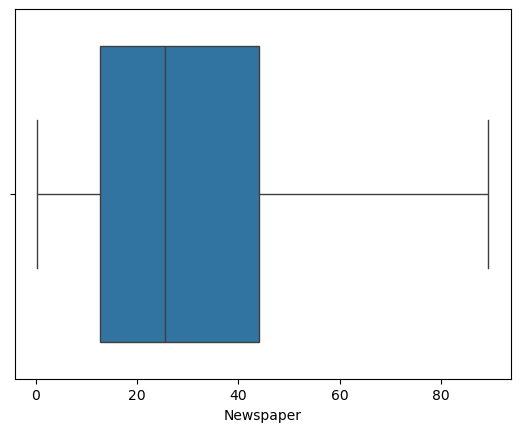

In [20]:
sns.boxplot(x=df['Newspaper'])
plt.show()

*   * Outlier udah di hapus dan sudah bersih dari outlier

* Melihat hasil pre-processing (Menggunakan Pairplot)

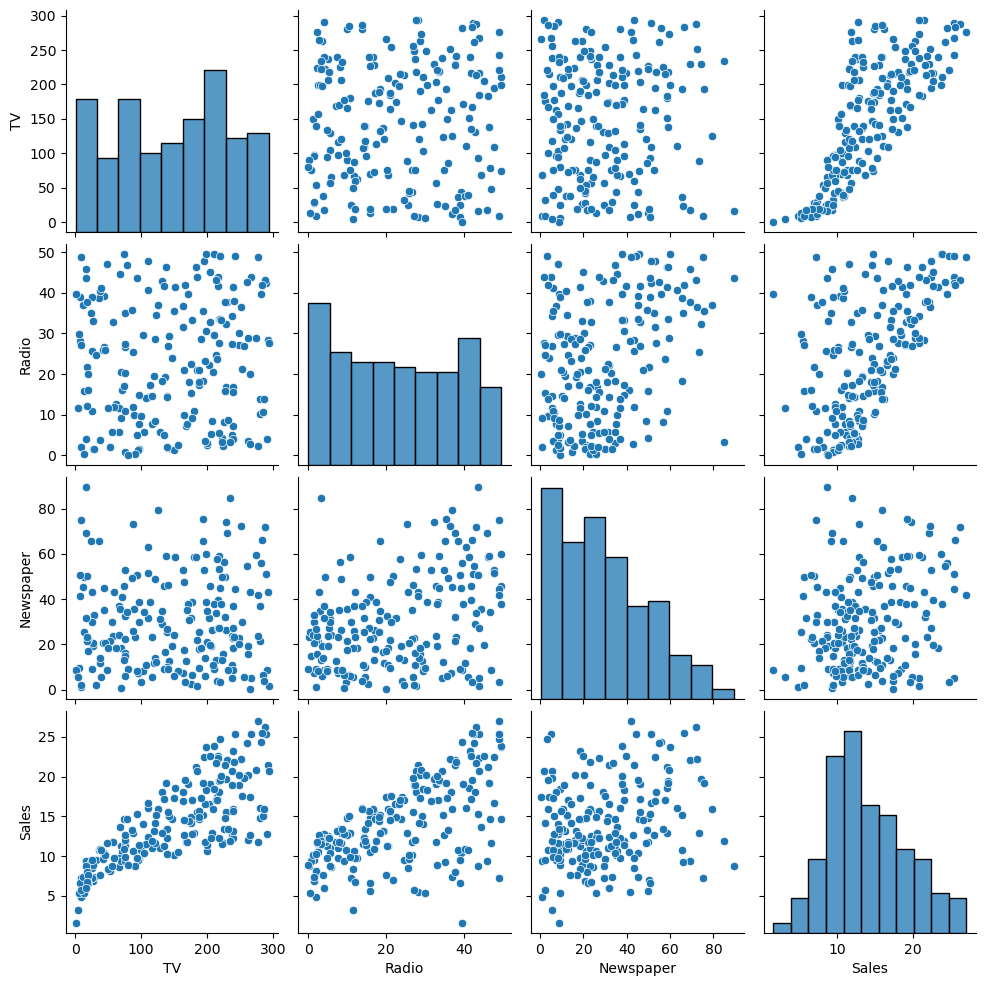

In [21]:
sns.pairplot(df)
plt.show()

**Modul 4** (Pemodelan)

* Splitting Data

In [22]:
df_train = df.sample(frac=0.8, random_state=42)
df_test = df.drop(df_train.index)

* Standarisasi Data

In [23]:
x_train = df_train[['Newspaper', 'TV', 'Radio']]
y_train = df_train['Sales']
x_train_std = x_train.std()
x_tr_stdz = (x_train - x_train.mean()) / x_train_std

x_test = df_test[['Newspaper', 'TV', 'Radio']]
x_te_stdz = (x_test - x_train.mean()) / x_train_std
y_test = df_test['Sales']

In [24]:
x_tr_stdz.describe()

,Newspaper,TV,Radio
count,1.580000e+02,1.580000e+02,1.580000e+02
mean,-1.826949e-16,1.517773e-16,-2.136125e-16
std,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.452425e+00,-1.731323e+00,-1.547461e+00
25%,-8.068541e-01,-8.501131e-01,-8.515409e-01
50%,-2.592137e-01,4.352447e-02,-8.620196e-02
75%,6.582450e-01,8.433597e-01,8.561542e-01
max,2.902926e+00,1.735518e+00,1.881813e+00


In [25]:
x_te_stdz.describe()

,Newspaper,TV,Radio
count,40.000000,40.000000,40.000000
mean,0.331207,-0.016663,0.288311
std,1.222536,1.067944,1.132693
min,-1.359649,-1.640183,-1.519694
25%,-0.868705,-1.014045,-0.898398
50%,0.328372,-0.144080,0.420553
75%,1.091203,0.858155,1.232750
max,3.140022,1.664500,1.895696


* Menggunakan rumus Multilpe Linear Regression

In [26]:
class multiple_liner:
    def __init__(self):
        self.beta=None

    def bias(self, x):
        return np.c_[np.ones(x.shape[0]), x]

    def fit(self, x_train, y_train):
        x_train_b = self.bias(x_train)
        self.beta = np.linalg.inv(x_train_b.T @ x_train_b) @ x_train_b.T @ y_train

    def predict(self, x):
        y_pred = self.bias(x) @ self.beta
        return y_pred


* Training Data

In [27]:
model = multiple_liner()

In [28]:
model.fit(x_tr_stdz, y_train)

* Model beta

In [29]:
beta = model.beta

In [30]:
beta

array([13.85063291, -0.10761147,  3.82958138,  2.64018822])

* Prediksi menggunakan data train

In [31]:
y_pr_train = model.predict(x_tr_stdz)

* Prediksi menggunakan data test

In [32]:
y_pr_test = model.predict(x_te_stdz)

**Modul 5** (Evaluasi)

* Menentukan R-square, MSE, MAE, dan RMSE

In [33]:
def eval (y, y_pred):
    r2 = 1 - (np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2))
    mse = np.mean((y - y_pred)**2)
    mae = np.mean(np.abs(y - y_pred))
    rmse = np.sqrt(mse)

    print(f'Root Squared : {r2 * 100:.2f}%')
    print(f'MSE : {mse}')
    print(f'MAE :{mae}')
    print(f'RMSE :{rmse}')

In [34]:
eval(y_test, y_pr_test)

Root Squared : 91.31%
MSE : 2.8070371965599263
MAE :1.4406815591236024
RMSE :1.675421498178869


* Melihat Grafik Prediksi data train

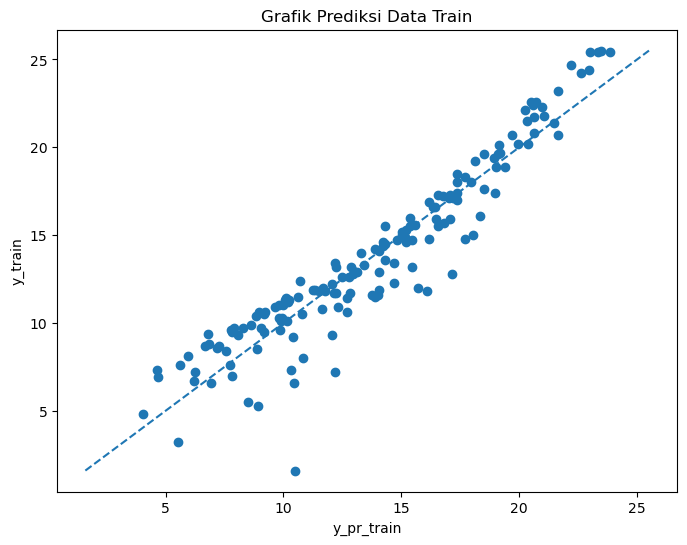

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_pr_train, y_train)

min_value = min(y_pr_train.min(), y_train.min())
max_value = max(y_pr_train.max(), y_train.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('y_pr_train')
plt.ylabel('y_train')
plt.title('Grafik Prediksi Data Train')
plt.show()

* Melihat Grafik prediksi data test

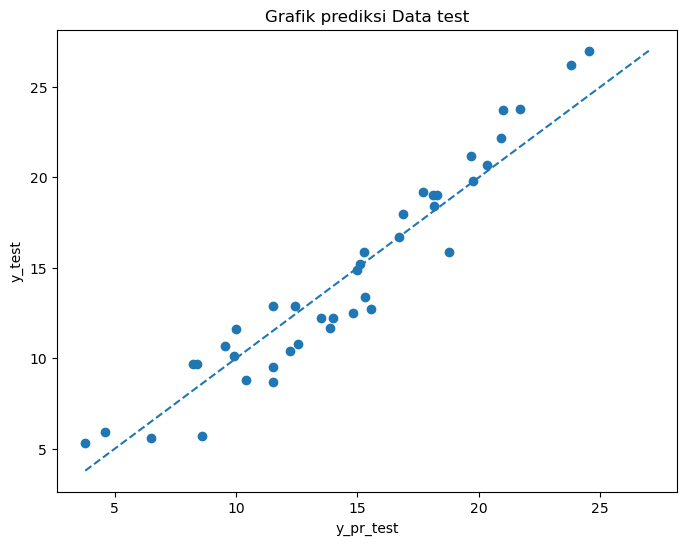

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_pr_test, y_test)

min_value = min(y_pr_test.min(), y_test.min())
max_value = max(y_pr_test.max(), y_test.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('y_pr_test')
plt.ylabel('y_test')
plt.title('Grafik prediksi Data test')

plt.show()

**Modul 6** (GUI)

In [ ]:

import tkinter as tk
from tkinter import messagebox
import pandas as pd
import numpy as np

# 1. Load dataset
data = pd.read_csv("Advertising.csv")

# 2. Tentukan input dan target
X = data[["TV", "Radio", "Newspaper"]]
y = data["Sales"]

# 3. Latih model regresi linear berganda
X_np = X.to_numpy()
y_np = y.to_numpy()

# Tambahkan kolom 1 untuk intercept
X_b = np.c_[np.ones((X_np.shape[0], 1)), X_np]

# Hitung koefisien regresi
theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y_np


# 4. Fungsi prediksi
def prediksi():
    try:
        # Ambil input dari GUI
        tv = float(entry_tv.get())
        radio = float(entry_radio.get())
        newspaper = float(entry_newspaper.get())

        # Validasi input
        if tv < 0 or radio < 0 or newspaper < 0:
            messagebox.showerror(
                "Input Tidak Valid",
                "Biaya iklan tidak boleh negatif!"
            )
            return

        # Hitung total budget
        total_budget = tv + radio + newspaper

        # Siapkan data untuk prediksi
        input_data = np.array([1, tv, radio, newspaper])

        # Hitung prediksi Sales
        hasil = input_data @ theta

        # Susun hasil agar mudah dibaca
        pesan = (
            "HASIL PREDIKSI PENJUALAN\n"
            "========================\n\n"

            "BUDGET IKLAN\n"
            f"TV          : {tv:,.2f}\n"
            f"Radio       : {radio:,.2f}\n"
            f"Newspaper   : {newspaper:,.2f}\n"
            "------------------------\n"
            f"Total Budget: {total_budget:,.2f}\n\n"

            "HASIL MODEL\n"
            f"Prediksi Sales: {hasil:.2f}\n\n"

            "Catatan:\n"
            "Sales mengikuti satuan pada dataset.\n"
            "Jika Sales diukur dalam ribuan unit,\n"
            f"prediksi setara sekitar {hasil * 1000:,.0f} unit."
        )

        messagebox.showinfo("Advertising Sales Prediction", pesan)

    except ValueError:
        messagebox.showerror(
            "Input Tidak Valid",
            "Masukkan angka yang benar pada semua kolom!"
        )

    except Exception as e:
        messagebox.showerror(
            "Terjadi Kesalahan",
            str(e)
        )


# 5. Buat window GUI
window = tk.Tk()
window.title("Advertising Sales Prediction")
window.geometry("400x370")
window.resizable(False, False)

# 6. Judul
tk.Label(
    window,
    text="Advertising Sales Prediction",
    font=("Arial", 14, "bold")
).pack(pady=(15, 5))

tk.Label(
    window,
    text="Masukkan budget untuk setiap media iklan"
).pack(pady=(0, 10))


# 7. Input TV
tk.Label(window, text="Budget Iklan TV").pack()
entry_tv = tk.Entry(window)
entry_tv.pack(pady=(3, 8))


# 8. Input Radio
tk.Label(window, text="Budget Iklan Radio").pack()
entry_radio = tk.Entry(window)
entry_radio.pack(pady=(3, 8))


# 9. Input Newspaper
tk.Label(window, text="Budget Iklan Newspaper").pack()
entry_newspaper = tk.Entry(window)
entry_newspaper.pack(pady=(3, 8))


# 10. Tombol prediksi
tk.Button(
    window,
    text="Hitung Prediksi Penjualan",
    command=prediksi
).pack(pady=15)


# 11. Jalankan GUI
window.mainloop()